# OTel Release vs Energy per Request

This notebook compares **energy/request** across OTel Demo releases with:
- x-axis: OTel release
- y-axis: Energy per request (J/request)
- series: low, medium, high
- separate panels: workstation (`eoan_`) and EC2 (`julian_`)

Data source: each experiment folder's `runs_comparison.html` (`const data = {...}` payload).

In [24]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

RUNS_ROOT = Path('../final-runs/experiment-runs-with-attribution')

# Folder name -> release label
RELEASE_MAP = {
    'otel-demo-1.12.0': '1.12.0',
    'otel-demo-2.0.0': '2.0.0',
    'otel-demo': '2.2.0',
}

RELEASE_ORDER = ['1.12.0', '2.0.0', '2.2.0']
WORKLOAD_ORDER = ['low', 'medium', 'high']
ENV_ORDER = ['workstation', 'ec2']

missing = [name for name in RELEASE_MAP if not (RUNS_ROOT / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing release folders under {RUNS_ROOT}: {missing}')

RUNS_ROOT.resolve()

PosixPath('/Users/eoan/Sites/univaq/phd/energyAnalyser/controller/final-runs/experiment-runs-with-attribution')

In [25]:
def extract_json_object_after_marker(text: str, marker: str) -> dict:
    marker_idx = text.find(marker)
    if marker_idx < 0:
        raise ValueError(f'Marker not found: {marker}')

    start = text.find('{', marker_idx)
    if start < 0:
        raise ValueError('Could not find JSON object start after marker')

    depth = 0
    in_string = False
    escaped = False

    for i in range(start, len(text)):
        ch = text[i]

        if in_string:
            if escaped:
                escaped = False
            elif ch == '\\':
                escaped = True
            elif ch == '"':
                in_string = False
            continue

        if ch == '"':
            in_string = True
            continue

        if ch == '{':
            depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                return json.loads(text[start:i + 1])

    raise ValueError('Could not find end of JSON object')

def environment_from_folder(name: str) -> str | None:
    if name.startswith('eoan_'):
        return 'workstation'
    if name.startswith('julian_'):
        return 'ec2'
    return None

rows = []

for folder_name, release in RELEASE_MAP.items():
    release_dir = RUNS_ROOT / folder_name

    for experiment_dir in sorted(release_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue

        env = environment_from_folder(experiment_dir.name)
        if env is None:
            continue

        dashboard_path = experiment_dir / 'runs_comparison.html'
        if not dashboard_path.exists():
            continue

        html = dashboard_path.read_text(encoding='utf-8')
        payload = extract_json_object_after_marker(html, 'const data = ')

        for run in payload.get('runs', []):
            wl = str(run.get('workload_level', '')).lower()
            if wl not in WORKLOAD_ORDER:
                continue

            epr = run.get('energy_per_request')
            if epr is None:
                epr = run.get('meter_energy_per_request_joules')

            if epr is None:
                continue

            try:
                epr = float(epr)
            except (TypeError, ValueError):
                continue

            rows.append({
                'release': release,
                'environment': env,
                'workload_level': wl,
                'energy_per_request_j': epr,
                'experiment_folder': experiment_dir.name,
                'run_name': run.get('name', ''),
            })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError('No runs were parsed. Check folder paths and dashboard format.')

df['release'] = pd.Categorical(df['release'], categories=RELEASE_ORDER, ordered=True)
df['workload_level'] = pd.Categorical(df['workload_level'], categories=WORKLOAD_ORDER, ordered=True)
df['environment'] = pd.Categorical(df['environment'], categories=ENV_ORDER, ordered=True)

agg = (
    df.groupby(['environment', 'release', 'workload_level'], observed=True)
      .agg(
          mean_energy_per_request_j=('energy_per_request_j', 'mean'),
          std_energy_per_request_j=('energy_per_request_j', 'std'),
          n=('energy_per_request_j', 'size'),
      )
      .reset_index()
)

print('Parsed runs:', len(df))
print('Grouped rows:', len(agg))
agg.head(12)

Parsed runs: 90
Grouped rows: 18


,environment,release,workload_level,mean_energy_per_request_j,std_energy_per_request_j,n
0,workstation,1.12.0,low,0.002025,0.000069,5
1,workstation,1.12.0,medium,0.001184,0.000039,5
2,workstation,1.12.0,high,0.001075,0.000042,5
3,workstation,2.0.0,low,0.001948,0.000085,5
4,workstation,2.0.0,medium,0.001206,0.000026,5
5,workstation,2.0.0,high,0.001077,0.000023,5
6,workstation,2.2.0,low,0.002026,0.000065,5
7,workstation,2.2.0,medium,0.001212,0.000038,5
8,workstation,2.2.0,high,0.001055,0.000040,5
9,ec2,1.12.0,low,1.756969,0.020435,5


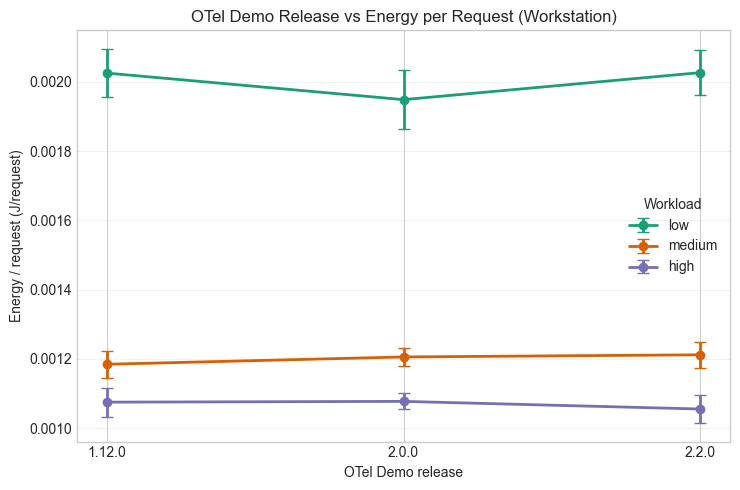

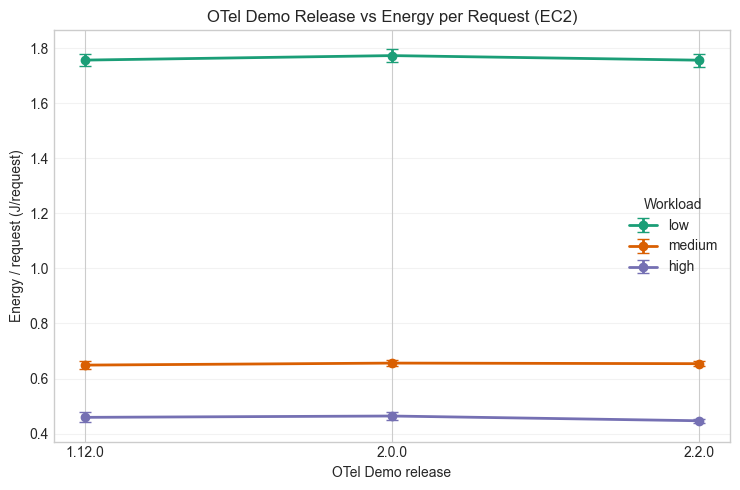

In [26]:
colors = {'low': '#1b9e77', 'medium': '#d95f02', 'high': '#7570b3'}

for env in ENV_ORDER:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    env_data = agg[agg['environment'] == env].copy()

    for wl in WORKLOAD_ORDER:
        s = env_data[env_data['workload_level'] == wl].sort_values('release')
        if s.empty:
            continue

        y = s['mean_energy_per_request_j'].to_numpy()
        yerr = s['std_energy_per_request_j'].fillna(0).to_numpy()

        ax.errorbar(
            s['release'].astype(str),
            y,
            yerr=yerr,
            marker='o',
            capsize=4,
            linewidth=2,
            color=colors[wl],
            label=wl,
        )

    panel_name = 'Workstation' if env == 'workstation' else 'EC2'
    ax.set_title(f'OTel Demo Release vs Energy per Request ({panel_name})')
    ax.set_xlabel('OTel Demo release')
    ax.set_ylabel('Energy / request (J/request)')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(title='Workload')

    fig.tight_layout()
    plt.show()

In [27]:
# Optional: compact table view used by the chart
table = agg.copy()
table['mean_energy_per_request_j'] = table['mean_energy_per_request_j'].round(6)
table['std_energy_per_request_j'] = table['std_energy_per_request_j'].round(6)
table.sort_values(['environment', 'workload_level', 'release']).reset_index(drop=True)

,environment,release,workload_level,mean_energy_per_request_j,std_energy_per_request_j,n
0,workstation,1.12.0,low,0.002025,0.000069,5
1,workstation,2.0.0,low,0.001948,0.000085,5
2,workstation,2.2.0,low,0.002026,0.000065,5
3,workstation,1.12.0,medium,0.001184,0.000039,5
4,workstation,2.0.0,medium,0.001206,0.000026,5
5,workstation,2.2.0,medium,0.001212,0.000038,5
6,workstation,1.12.0,high,0.001075,0.000042,5
7,workstation,2.0.0,high,0.001077,0.000023,5
8,workstation,2.2.0,high,0.001055,0.000040,5
9,ec2,1.12.0,low,1.756969,0.020435,5


## EnergyBench MS Motivation Figure Sequence

Step 1: Raw system energy shows that releases differ, but it does not tell us whether one release is more efficient.

In [28]:
from pathlib import Path

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RELEASE_ORDER_PAPER = ['v1.12.0', 'v2.0.0', 'v2.2.0']
WORKLOAD_ORDER_PAPER = ['high', 'medium', 'low']
ENV_ORDER_PAPER = ['workstation', 'ec2']

RELEASE_MAP_PAPER = {
    'otel-demo-1.12.0': 'v1.12.0',
    'otel-demo-2.0.0': 'v2.0.0',
    'otel-demo': 'v2.2.0',
}

def load_release_runs_and_attribution(runs_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    run_rows = []
    attr_rows = []

    for folder_name, release in RELEASE_MAP_PAPER.items():
        release_dir = runs_root / folder_name
        if not release_dir.exists():
            print(f'WARNING: missing release folder: {release_dir}')
            continue

        for experiment_dir in sorted(release_dir.iterdir()):
            if not experiment_dir.is_dir():
                continue

            env = environment_from_folder(experiment_dir.name)
            if env is None:
                continue

            dashboard_path = experiment_dir / 'runs_comparison.html'
            if not dashboard_path.exists():
                print(f'WARNING: missing dashboard file: {dashboard_path}')
                continue

            html = dashboard_path.read_text(encoding='utf-8')
            payload = extract_json_object_after_marker(html, 'const data = ')

            for run in payload.get('runs', []):
                workload = str(run.get('workload_level', '')).lower()
                if workload not in WORKLOAD_ORDER_PAPER:
                    continue

                epr = run.get('energy_per_request')
                if epr is None:
                    epr = run.get('meter_energy_per_request_joules')

                total_energy = run.get('energy_total')
                if total_energy is None:
                    total_energy = run.get('meter_corrected_energy_joules')

                run_rows.append({
                    'release': release,
                    'environment': env,
                    'workload_level': workload,
                    'energy_per_request_j': pd.to_numeric(epr, errors='coerce'),
                    'total_system_energy_j': pd.to_numeric(total_energy, errors='coerce'),
                    'experiment_folder': experiment_dir.name,
                    'run_name': run.get('name', ''),
                })

            workloads_payload = ((payload.get('attribution_phase1') or {}).get('workloads') or {})
            for workload_name, workload_payload in workloads_payload.items():
                if workload_name not in WORKLOAD_ORDER_PAPER:
                    continue

                models = (workload_payload.get('models') or {})
                for model_name, model_payload in models.items():
                    services = (model_payload.get('services') or {})
                    for service_name, stats in services.items():
                        attr_rows.append({
                            'release': release,
                            'environment': env,
                            'workload_level': workload_name,
                            'model': model_name,
                            'service': service_name,
                            'mean_attributed_energy_j': pd.to_numeric(stats.get('mean'), errors='coerce'),
                            'experiment_folder': experiment_dir.name,
                        })

    runs_df = pd.DataFrame(run_rows)
    attr_df = pd.DataFrame(attr_rows)

    if not runs_df.empty:
        runs_df['release'] = pd.Categorical(runs_df['release'], categories=RELEASE_ORDER_PAPER, ordered=True)
        runs_df['workload_level'] = pd.Categorical(runs_df['workload_level'], categories=WORKLOAD_ORDER_PAPER, ordered=True)
        runs_df['environment'] = pd.Categorical(runs_df['environment'], categories=ENV_ORDER_PAPER, ordered=True)

    if not attr_df.empty:
        attr_df['release'] = pd.Categorical(attr_df['release'], categories=RELEASE_ORDER_PAPER, ordered=True)
        attr_df['workload_level'] = pd.Categorical(attr_df['workload_level'], categories=WORKLOAD_ORDER_PAPER, ordered=True)
        attr_df['environment'] = pd.Categorical(attr_df['environment'], categories=ENV_ORDER_PAPER, ordered=True)

    return runs_df, attr_df

def _warn_missing_combinations(df: pd.DataFrame, metric_col: str, context: str) -> None:
    expected = pd.MultiIndex.from_product(
        [ENV_ORDER_PAPER, RELEASE_ORDER_PAPER, WORKLOAD_ORDER_PAPER],
        names=['environment', 'release', 'workload_level'],
    )

    present = (
        df.dropna(subset=[metric_col])[['environment', 'release', 'workload_level']]
          .drop_duplicates()
          .set_index(['environment', 'release', 'workload_level'])
          .index
    )

    missing = expected.difference(present)
    for env, rel, wl in missing.tolist():
        print(f'WARNING: missing {context} data for environment={env}, release={rel}, workload={wl}')

def prepare_release_summary(runs_df: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    _warn_missing_combinations(runs_df, metric_col, metric_col)

    summary = (
        runs_df.groupby(['environment', 'release', 'workload_level'], observed=True)
               .agg(
                    mean=(metric_col, 'mean'),
                    std=(metric_col, 'std'),
                    n=(metric_col, 'size'),
               )
               .reset_index()
    )

    summary['std'] = summary['std'].fillna(0)
    summary['cv'] = summary['std'] / summary['mean']
    return summary

def _save_figure(fig: plt.Figure, stem: str) -> None:
    png_path = FIGURES_DIR / f'{stem}.png'
    pdf_path = FIGURES_DIR / f'{stem}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f'Saved: {png_path}')
    print(f'Saved: {pdf_path}')

def plot_total_energy_by_release(summary_df: pd.DataFrame) -> None:
    colors = {'low': '#1f77b4', 'medium': '#ff7f0e', 'high': '#2ca02c'}

    for env in ENV_ORDER_PAPER:
        fig, ax = plt.subplots(figsize=(7.5, 5))
        env_data = summary_df[summary_df['environment'] == env]

        for wl in WORKLOAD_ORDER_PAPER:
            s = env_data[env_data['workload_level'] == wl].sort_values('release')
            if s.empty:
                print(f'WARNING: no total energy rows for environment={env}, workload={wl}')
                continue

            ax.errorbar(
                s['release'].astype(str),
                s['mean'],
                yerr=s['std'],
                marker='o',
                capsize=4,
                linewidth=2,
                color=colors[wl],
                label=wl,
            )

        panel = 'workstation' if env == 'workstation' else 'ec2'
        ax.set_title('Total system energy across OTel Demo releases')
        ax.set_xlabel('OTel Demo release')
        ax.set_ylabel('Mean total system energy (J)')
        ax.grid(True, axis='y', alpha=0.25)
        ax.legend(title='Workload')

        fig.tight_layout()
        _save_figure(fig, f'chart1_total_system_energy_{panel}')
        plt.show()

def plot_energy_per_request_by_release(summary_df: pd.DataFrame) -> None:
    colors = {'low': '#1f77b4', 'medium': '#ff7f0e', 'high': '#2ca02c'}

    for env in ENV_ORDER_PAPER:
        fig, ax = plt.subplots(figsize=(7.5, 5))
        env_data = summary_df[summary_df['environment'] == env]

        for wl in WORKLOAD_ORDER_PAPER:
            s = env_data[env_data['workload_level'] == wl].sort_values('release')
            if s.empty:
                print(f'WARNING: no energy/request rows for environment={env}, workload={wl}')
                continue

            ax.errorbar(
                s['release'].astype(str),
                s['mean'],
                yerr=s['std'],
                marker='o',
                capsize=4,
                linewidth=2,
                color=colors[wl],
                label=wl,
            )

        panel = 'workstation' if env == 'workstation' else 'ec2'
        ax.set_title('Energy per request across OTel Demo releases')
        ax.set_xlabel('OTel Demo release')
        ax.set_ylabel('Mean energy / request (J/request)')
        ax.grid(True, axis='y', alpha=0.25)
        ax.legend(title='Workload')

        fig.tight_layout()
        _save_figure(fig, f'chart2_energy_per_request_{panel}')
        plt.show()

def prepare_attribution_percentages(
    attr_df: pd.DataFrame,
    environment: str = 'workstation',
    workload_level: str = 'medium',
    model: str = 'M1',
) -> pd.DataFrame:
    subset = attr_df[
        (attr_df['environment'] == environment)
        & (attr_df['workload_level'] == workload_level)
        & (attr_df['model'] == model)
    ].copy()

    if subset.empty:
        print(f'WARNING: no attribution rows for environment={environment}, workload={workload_level}, model={model}')
        return subset

    per_service = (
        subset.groupby(['release', 'service'], observed=True)['mean_attributed_energy_j']
              .mean()
              .reset_index()
    )

    release_totals = per_service.groupby('release', observed=True)['mean_attributed_energy_j'].transform('sum')
    per_service['pct'] = (per_service['mean_attributed_energy_j'] / release_totals) * 100

    for rel in RELEASE_ORDER_PAPER:
        rel_rows = per_service[per_service['release'] == rel].sort_values('pct', ascending=False)
        if rel_rows.empty:
            print(f'WARNING: no attribution percentage rows for release={rel}')
            continue

        print(f'Top services for {rel} ({environment}, {workload_level}, {model}):')
        print(rel_rows[['service', 'pct']].head(10).to_string(index=False))

    return per_service

def plot_service_attribution_by_release(percentage_df: pd.DataFrame) -> None:
    if percentage_df.empty:
        print('WARNING: no data to plot for service attribution chart')
        return

    top_services = ['load-generator', 'frontend', 'product-catalog', 'frontend-proxy', 'kafka', 'product-reviews']

    pivot = (
        percentage_df.pivot_table(
            index='release',
            columns='service',
            values='pct',
            aggfunc='mean',
        )
        .reindex(RELEASE_ORDER_PAPER)
        .fillna(0)
    )

    missing_expected = [svc for svc in top_services if svc not in pivot.columns]
    for svc in missing_expected:
        print(f'WARNING: expected top service not found in attribution data: {svc}')
        pivot[svc] = 0.0

    other_cols = [c for c in pivot.columns if c not in top_services]
    ordered = pivot[top_services].copy()
    ordered['Other'] = pivot[other_cols].sum(axis=1) if other_cols else 0.0

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    bottom = pd.Series(0.0, index=ordered.index)
    colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#bab0ab']

    for idx, service in enumerate(ordered.columns):
        vals = ordered[service]
        ax.bar(
            ordered.index.astype(str),
            vals,
            bottom=bottom,
            label=service,
            color=colors[idx % len(colors)],
            edgecolor='white',
            linewidth=0.5,
        )
        bottom = bottom + vals

    ax.set_title('Service-level attributed energy distribution across releases')
    ax.set_xlabel('OTel Demo release')
    ax.set_ylabel('Attributed energy share (%)')
    ax.set_ylim(0, 100)
    ax.legend(title='Service', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, axis='y', alpha=0.25)

    fig.tight_layout()
    _save_figure(fig, 'chart3_service_attribution_workstation_medium_m1')
    plt.show()

runs_df_paper, attr_df_paper = load_release_runs_and_attribution(RUNS_ROOT)
print('Runs rows loaded:', len(runs_df_paper))
print('Attribution rows loaded:', len(attr_df_paper))
FIGURES_DIR.resolve()

Runs rows loaded: 90
Attribution rows loaded: 792


PosixPath('/Users/eoan/Sites/univaq/phd/energyAnalyser/controller/visualizations/figures')

Step 1: Raw system energy shows that releases differ, but it does not tell us whether one release is more efficient.

Raw energy changes across releases, but total energy alone does not account for the amount of work performed.

Saved: figures/chart1_total_system_energy_workstation.png
Saved: figures/chart1_total_system_energy_workstation.pdf


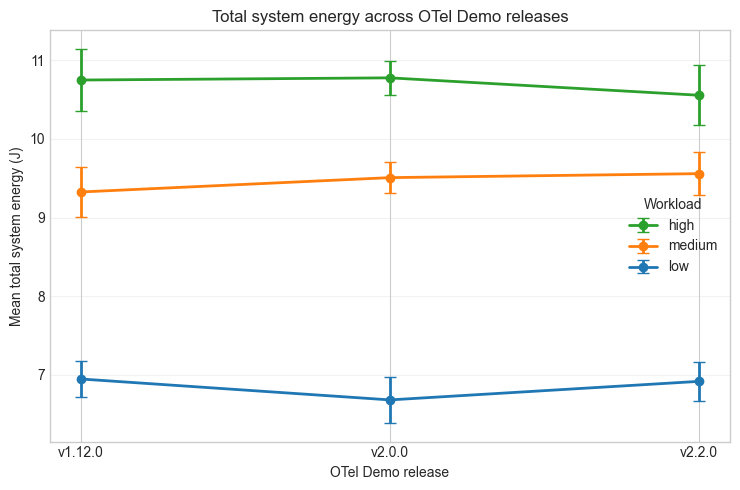

Saved: figures/chart1_total_system_energy_ec2.png
Saved: figures/chart1_total_system_energy_ec2.pdf


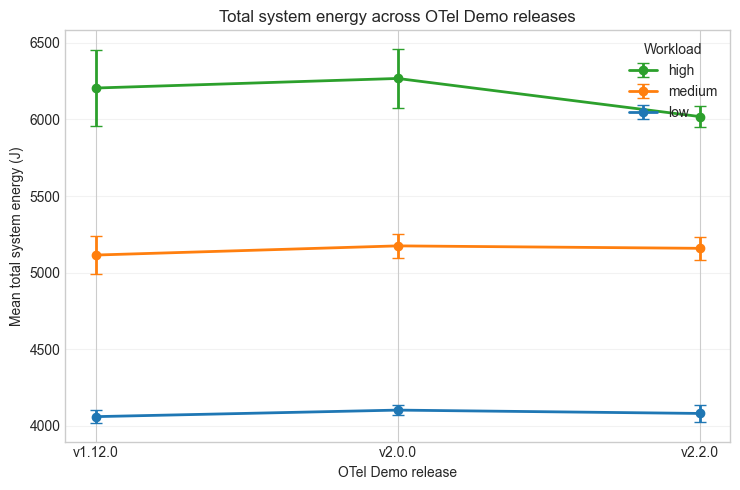

,environment,release,workload_level,mean,std,n,cv
0,workstation,v1.12.0,high,10.748167,0.393097,5,0.036573
1,workstation,v2.0.0,high,10.775781,0.218283,5,0.020257
2,workstation,v2.2.0,high,10.554603,0.379323,5,0.035939
3,workstation,v1.12.0,medium,9.324751,0.315095,5,0.033791
4,workstation,v2.0.0,medium,9.507233,0.197726,5,0.020797
5,workstation,v2.2.0,medium,9.557786,0.272028,5,0.028461
6,workstation,v1.12.0,low,6.947128,0.223569,5,0.032181
7,workstation,v2.0.0,low,6.681227,0.292232,5,0.043739
8,workstation,v2.2.0,low,6.917108,0.252359,5,0.036483
9,ec2,v1.12.0,high,6204.275267,247.319286,5,0.039863


In [29]:
total_energy_summary = prepare_release_summary(runs_df_paper, 'total_system_energy_j')
plot_total_energy_by_release(total_energy_summary)

total_energy_table = total_energy_summary.copy()
total_energy_table['mean'] = total_energy_table['mean'].round(6)
total_energy_table['std'] = total_energy_table['std'].round(6)
total_energy_table['cv'] = total_energy_table['cv'].round(6)
total_energy_table.sort_values(['environment', 'workload_level', 'release']).reset_index(drop=True)

Step 2: Energy per request normalises by useful work, but it remains an end-to-end indicator.

Normalising by requests makes release-level comparisons more meaningful, but still does not explain which services are responsible.

Saved: figures/chart2_energy_per_request_workstation.png
Saved: figures/chart2_energy_per_request_workstation.pdf


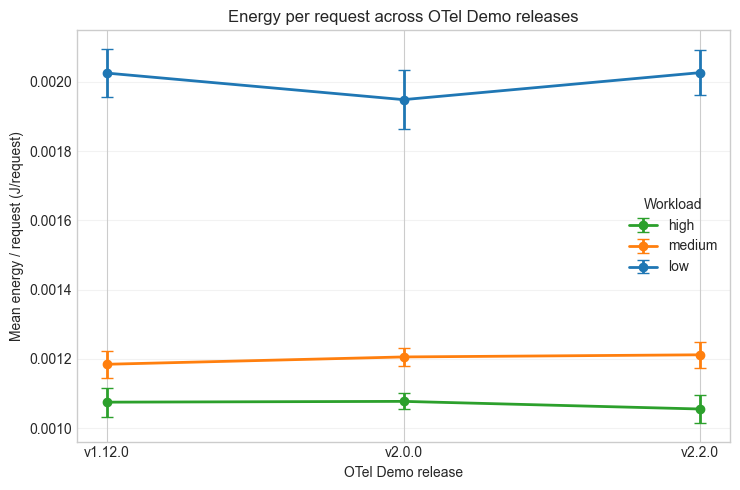

Saved: figures/chart2_energy_per_request_ec2.png
Saved: figures/chart2_energy_per_request_ec2.pdf


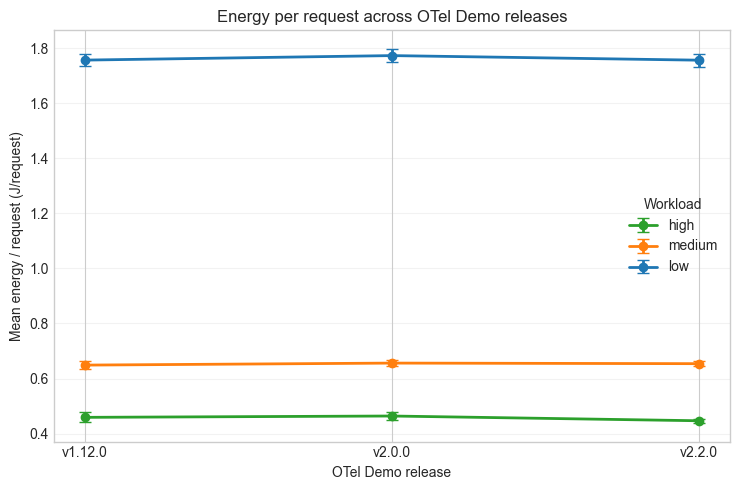

,environment,release,workload_level,mean,std,n,cv
0,workstation,v1.12.0,high,0.001075,0.000042,5,0.038907
1,workstation,v2.0.0,high,0.001077,0.000023,5,0.021412
2,workstation,v2.2.0,high,0.001055,0.000040,5,0.037974
3,workstation,v1.12.0,medium,0.001184,0.000039,5,0.033217
4,workstation,v2.0.0,medium,0.001206,0.000026,5,0.021251
5,workstation,v2.2.0,medium,0.001212,0.000038,5,0.030967
6,workstation,v1.12.0,low,0.002025,0.000069,5,0.034181
7,workstation,v2.0.0,low,0.001948,0.000085,5,0.043656
8,workstation,v2.2.0,low,0.002026,0.000065,5,0.032314
9,ec2,v1.12.0,high,0.458915,0.018208,5,0.039676


In [30]:
energy_per_request_summary = prepare_release_summary(runs_df_paper, 'energy_per_request_j')
plot_energy_per_request_by_release(energy_per_request_summary)

energy_per_request_table = energy_per_request_summary.copy()
energy_per_request_table['mean'] = energy_per_request_table['mean'].round(6)
energy_per_request_table['std'] = energy_per_request_table['std'].round(6)
energy_per_request_table['cv'] = energy_per_request_table['cv'].round(6)
energy_per_request_table.sort_values(['environment', 'workload_level', 'release']).reset_index(drop=True)

Step 3: Service-level attribution is needed to inspect where energy is consumed inside the microservice architecture.

Attribution exposes where energy is distributed inside the application, which end-to-end metrics cannot explain.

Absolute attributed energy table (J), mean +- std:


release,v1.12.0 mean (J),v2.0.0 mean (J),v2.2.0 mean (J),v1.12.0 std (J),v2.0.0 std (J),v2.2.0 std (J)
service,,,,,,
frontend,51.9640,52.0151,52.9453,1.3725,1.3539,1.4960
product-catalog,49.3422,52.2563,54.3663,4.1113,1.1878,2.4916
kafka,4.5410,4.5287,4.4461,0.1854,0.1863,0.0427
load-generator,68.0062,67.7618,67.2418,1.1238,2.3496,1.1699
frontend-proxy,8.4913,8.5086,8.6234,0.2161,0.2150,0.1591
product-reviews,2.3283,2.3438,2.2654,0.1392,0.3412,0.2213


Saved: figures/chart3_service_attribution_workstation_medium_m1_absolute_with_std.png
Saved: figures/chart3_service_attribution_workstation_medium_m1_absolute_with_std.pdf


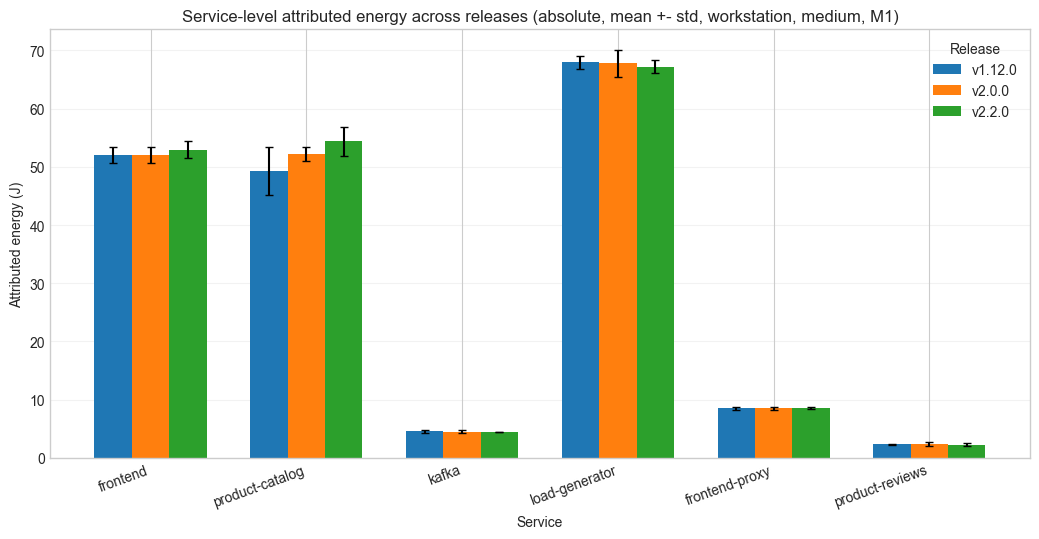

In [31]:
# Absolute attribution chart with uncertainty (mean +- std across 5 runs)
env_sel = 'workstation'
workload_sel = 'medium'
model_sel = 'M1'

service_order = [
    'frontend',
    'product-catalog',
    'kafka',
    'load-generator',
    'frontend-proxy',
    'product-reviews',
]

rows = []

for folder_name, release in RELEASE_MAP_PAPER.items():
    release_dir = RUNS_ROOT / folder_name
    if not release_dir.exists():
        print(f'WARNING: missing release folder for attribution: {release_dir}')
        continue

    matched_experiments = [
        d for d in sorted(release_dir.iterdir())
        if d.is_dir() and environment_from_folder(d.name) == env_sel
    ]

    if not matched_experiments:
        print(f'WARNING: no experiment found for environment={env_sel}, release={release}')
        continue

    for experiment_dir in matched_experiments:
        dashboard_path = experiment_dir / 'runs_comparison.html'
        if not dashboard_path.exists():
            print(f'WARNING: missing dashboard file: {dashboard_path}')
            continue

        payload = extract_json_object_after_marker(
            dashboard_path.read_text(encoding='utf-8'),
            'const data = ',
        )

        workload_payload = (((payload.get('attribution_phase1') or {}).get('workloads') or {}).get(workload_sel) or {})
        model_payload = ((workload_payload.get('models') or {}).get(model_sel) or {})
        services = model_payload.get('services') or {}

        if not services:
            print(
                f'WARNING: missing attribution services for environment={env_sel}, release={release}, '
                f'workload={workload_sel}, model={model_sel}'
            )
            continue

        for service in service_order:
            stats = services.get(service)
            if not stats:
                print(f'WARNING: missing service={service} for release={release}')
                rows.append({
                    'release': release,
                    'service': service,
                    'mean_j': np.nan,
                    'std_j': np.nan,
                })
                continue

            rows.append({
                'release': release,
                'service': service,
                'mean_j': pd.to_numeric(stats.get('mean'), errors='coerce'),
                'std_j': pd.to_numeric(stats.get('std'), errors='coerce'),
            })

if not rows:
    raise RuntimeError('No attribution rows found for absolute chart with uncertainty.')

svc_df = pd.DataFrame(rows)

agg_tbl = (
    svc_df.groupby(['service', 'release'], observed=True)
          .agg(
              mean_j=('mean_j', 'mean'),
              std_j=('std_j', 'mean'),
          )
          .reset_index()
          .pivot(index='service', columns='release', values=['mean_j', 'std_j'])
 )

mean_tbl = agg_tbl['mean_j'].reindex(service_order).reindex(columns=RELEASE_ORDER_PAPER)
std_tbl = agg_tbl['std_j'].reindex(service_order).reindex(columns=RELEASE_ORDER_PAPER)

for svc in service_order:
    if svc not in mean_tbl.index:
        print(f'WARNING: service missing in plotted table: {svc}')
        continue
    for rel in RELEASE_ORDER_PAPER:
        if pd.isna(mean_tbl.loc[svc, rel]):
            print(f'WARNING: missing mean attribution for service={svc}, release={rel}')
        if pd.isna(std_tbl.loc[svc, rel]):
            print(f'WARNING: missing std attribution for service={svc}, release={rel}')

print('Absolute attributed energy table (J), mean +- std:')
display(
    pd.concat([
        mean_tbl.add_suffix(' mean (J)'),
        std_tbl.add_suffix(' std (J)'),
    ], axis=1).round(4)
 )

x = np.arange(len(service_order))
width = 0.24
fig, ax = plt.subplots(figsize=(10.5, 5.5))

for idx, rel in enumerate(RELEASE_ORDER_PAPER):
    offset = (idx - 1) * width
    y = mean_tbl[rel].fillna(0.0).to_numpy()
    yerr = std_tbl[rel].fillna(0.0).to_numpy()
    ax.bar(
        x + offset,
        y,
        width=width,
        yerr=yerr,
        capsize=3,
        label=rel,
    )

ax.set_xticks(x)
ax.set_xticklabels(service_order, rotation=20, ha='right')
ax.set_xlabel('Service')
ax.set_ylabel('Attributed energy (J)')
ax.set_title('Service-level attributed energy across releases (absolute, mean +- std, workstation, medium, M1)')
ax.legend(title='Release')
ax.grid(True, axis='y', alpha=0.25)

fig.tight_layout()
png_path = FIGURES_DIR / 'chart3_service_attribution_workstation_medium_m1_absolute_with_std.png'
pdf_path = FIGURES_DIR / 'chart3_service_attribution_workstation_medium_m1_absolute_with_std.pdf'
fig.savefig(png_path, dpi=300, bbox_inches='tight')
fig.savefig(pdf_path, bbox_inches='tight')
print(f'Saved: {png_path}')
print(f'Saved: {pdf_path}')
plt.show()

Step 4: Fixed-utilisation normalisation compares releases or environments at comparable operating points.

This section uses per-iteration CPU telemetry (`cpu_total.json`) and run-level energy/request to test whether a common percentile baseline (e.g., p80 CPU) is valid across workstation and EC2, then compares energy/request only within shared CPU windows.

In [32]:
# Build per-iteration CPU percentile table from timestamped telemetry
PERCENTILE_CANDIDATES = [50, 70, 80, 90]
CPU_COLS = [f'cpu_p{p}' for p in PERCENTILE_CANDIDATES]

def _load_cpu_series_from_json(cpu_json_path: Path) -> pd.Series:
    payload = json.loads(cpu_json_path.read_text(encoding='utf-8'))
    result = (((payload.get('data') or {}).get('result')) or [])
    if not result:
        return pd.Series(dtype=float)

    values = (result[0].get('values') or [])
    if not values:
        return pd.Series(dtype=float)

    raw = pd.Series([v[1] for v in values], dtype='object')
    s = pd.to_numeric(raw, errors='coerce').dropna().astype(float)
    return s

cpu_rows = []

for folder_name, release in RELEASE_MAP_PAPER.items():
    release_dir = RUNS_ROOT / folder_name
    if not release_dir.exists():
        continue

    for experiment_dir in sorted(release_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue

        env = environment_from_folder(experiment_dir.name)
        if env is None:
            continue

        for workload_dir in sorted(experiment_dir.iterdir()):
            if not workload_dir.is_dir():
                continue

            workload = workload_dir.name.lower()
            if workload not in WORKLOAD_ORDER_PAPER:
                continue

            for iteration_dir in sorted(workload_dir.glob('iteration_*')):
                cpu_path = iteration_dir / 'cpu_total.json'
                if not cpu_path.exists():
                    continue

                cpu_series = _load_cpu_series_from_json(cpu_path)
                if cpu_series.empty:
                    continue

                row = {
                    'release': release,
                    'environment': env,
                    'workload_level': workload,
                    'experiment_folder': experiment_dir.name,
                    'iteration_name': iteration_dir.name,
                    'cpu_mean': float(cpu_series.mean()),
                    'cpu_std': float(cpu_series.std(ddof=0)),
                    'samples': int(cpu_series.shape[0]),
                }

                for p in PERCENTILE_CANDIDATES:
                    row[f'cpu_p{p}'] = float(np.percentile(cpu_series.to_numpy(), p))

                cpu_rows.append(row)

cpu_percentiles_df = pd.DataFrame(cpu_rows)
if cpu_percentiles_df.empty:
    raise RuntimeError('No CPU telemetry rows parsed from cpu_total.json')

cpu_percentiles_df['release'] = pd.Categorical(cpu_percentiles_df['release'], categories=RELEASE_ORDER_PAPER, ordered=True)
cpu_percentiles_df['workload_level'] = pd.Categorical(cpu_percentiles_df['workload_level'], categories=WORKLOAD_ORDER_PAPER, ordered=True)
cpu_percentiles_df['environment'] = pd.Categorical(cpu_percentiles_df['environment'], categories=ENV_ORDER_PAPER, ordered=True)

print('CPU percentile rows:', len(cpu_percentiles_df))
cpu_percentiles_df.head()

CPU percentile rows: 90


,release,environment,workload_level,experiment_folder,iteration_name,cpu_mean,cpu_std,samples,cpu_p50,cpu_p70,cpu_p80,cpu_p90
0,v1.12.0,workstation,high,eoan_20260601_165243_699668_otel-demo,iteration_20260601_182615_859046,8.663675,2.728349,25,9.297868,11.312176,11.537120,11.609328
1,v1.12.0,workstation,high,eoan_20260601_165243_699668_otel-demo,iteration_20260601_183327_365056,8.465634,2.509284,25,9.167296,10.881534,10.969572,11.084924
2,v1.12.0,workstation,high,eoan_20260601_165243_699668_otel-demo,iteration_20260601_184039_225250,8.634337,2.833487,25,9.323417,11.268438,11.619950,11.730180
3,v1.12.0,workstation,high,eoan_20260601_165243_699668_otel-demo,iteration_20260601_184752_636884,8.647943,2.620913,25,9.140510,11.013009,11.379632,11.652342
4,v1.12.0,workstation,high,eoan_20260601_165243_699668_otel-demo,iteration_20260601_185504_371106,8.401887,2.662114,25,8.986489,11.033952,11.148559,11.306095


In [33]:
# Join CPU percentiles with run-level energy/request, enforce Joules-only metric and source consistency
def _load_runs_with_explicit_energy_sources(runs_root: Path) -> pd.DataFrame:
    rows = []

    for folder_name, release in RELEASE_MAP_PAPER.items():
        release_dir = runs_root / folder_name
        if not release_dir.exists():
            continue

        for experiment_dir in sorted(release_dir.iterdir()):
            if not experiment_dir.is_dir():
                continue

            env = environment_from_folder(experiment_dir.name)
            if env is None:
                continue

            dashboard_path = experiment_dir / 'runs_comparison.html'
            if not dashboard_path.exists():
                continue

            payload = extract_json_object_after_marker(
                dashboard_path.read_text(encoding='utf-8'),
                'const data = ',
            )

            for run in payload.get('runs', []):
                wl = str(run.get('workload_level', '')).lower()
                if wl not in WORKLOAD_ORDER_PAPER:
                    continue

                run_name = str(run.get('name', ''))
                iteration_name = pd.Series([run_name]).str.extract(r'(iteration_[0-9_]+)', expand=False).iloc[0]

                model_epr_j = pd.to_numeric(run.get('energy_per_request'), errors='coerce')
                meter_epr_j = pd.to_numeric(run.get('meter_energy_per_request_joules'), errors='coerce')

                if pd.notna(meter_epr_j):
                    energy_per_request_j = float(meter_epr_j)
                    energy_source = 'meter_joules'
                elif pd.notna(model_epr_j):
                    energy_per_request_j = float(model_epr_j)
                    energy_source = 'model_joules'
                else:
                    energy_per_request_j = np.nan
                    energy_source = 'missing'

                rows.append({
                    'release': release,
                    'environment': env,
                    'workload_level': wl,
                    'experiment_folder': experiment_dir.name,
                    'iteration_name': iteration_name,
                    'energy_per_request_j': energy_per_request_j,
                    'energy_source': energy_source,
                })

    out = pd.DataFrame(rows)
    out = out.dropna(subset=['iteration_name']).copy()
    out['release'] = pd.Categorical(out['release'], categories=RELEASE_ORDER_PAPER, ordered=True)
    out['workload_level'] = pd.Categorical(out['workload_level'], categories=WORKLOAD_ORDER_PAPER, ordered=True)
    out['environment'] = pd.Categorical(out['environment'], categories=ENV_ORDER_PAPER, ordered=True)
    return out

runs_energy_df = _load_runs_with_explicit_energy_sources(RUNS_ROOT)
if runs_energy_df.empty:
    raise RuntimeError('No run-level energy rows found in runs_comparison payloads')

fixed_util_df = cpu_percentiles_df.merge(
    runs_energy_df,
    on=['release', 'environment', 'workload_level', 'experiment_folder', 'iteration_name'],
    how='inner',
)

fixed_util_df = fixed_util_df[fixed_util_df['energy_source'] != 'missing'].copy()
if fixed_util_df.empty:
    raise RuntimeError('CPU telemetry could not be joined with valid Joules energy rows')

source_by_env = (
    fixed_util_df.groupby('environment', observed=True)['energy_source']
                .agg(lambda s: sorted(set(s.dropna())))
                .to_dict()
)
print('Energy source(s) per environment:', source_by_env)

env_sources = [tuple(v) for v in source_by_env.values() if len(v) > 0]
if not env_sources or any(len(v) != 1 for v in env_sources) or len(set(env_sources)) != 1:
    raise RuntimeError(
        'Inconsistent energy source across environments for cross-env comparison. '
        f'Found: {source_by_env}. Use a single common source in Joules.'
    )

overlap_rows = []
for pct in PERCENTILE_CANDIDATES:
    col = f'cpu_p{pct}'

    grouped = fixed_util_df.groupby(['release', 'workload_level'], observed=True)
    for (release, workload), grp in grouped:
        ws = grp.loc[grp['environment'] == 'workstation', col].dropna()
        ec2 = grp.loc[grp['environment'] == 'ec2', col].dropna()

        if ws.empty or ec2.empty:
            overlap_rows.append({
                'release': release,
                'workload_level': workload,
                'percentile': pct,
                'ws_min': np.nan,
                'ws_max': np.nan,
                'ec2_min': np.nan,
                'ec2_max': np.nan,
                'overlap_low': np.nan,
                'overlap_high': np.nan,
                'overlap_width': np.nan,
                'has_overlap': False,
            })
            continue

        low = max(ws.min(), ec2.min())
        high = min(ws.max(), ec2.max())
        has_overlap = high >= low

        overlap_rows.append({
            'release': release,
            'workload_level': workload,
            'percentile': pct,
            'ws_min': float(ws.min()),
            'ws_max': float(ws.max()),
            'ec2_min': float(ec2.min()),
            'ec2_max': float(ec2.max()),
            'overlap_low': float(low),
            'overlap_high': float(high),
            'overlap_width': float(high - low) if has_overlap else np.nan,
            'has_overlap': bool(has_overlap),
        })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df['release'] = pd.Categorical(overlap_df['release'], categories=RELEASE_ORDER_PAPER, ordered=True)
overlap_df['workload_level'] = pd.Categorical(overlap_df['workload_level'], categories=WORKLOAD_ORDER_PAPER, ordered=True)

coverage_tbl = (
    overlap_df.groupby('percentile', observed=True)
              .agg(
                  groups=('has_overlap', 'size'),
                  groups_with_overlap=('has_overlap', 'sum'),
                  overlap_rate=('has_overlap', 'mean'),
                  mean_overlap_width=('overlap_width', 'mean'),
                  min_overlap_width=('overlap_width', 'min'),
              )
              .reset_index()
              .sort_values(['overlap_rate', 'mean_overlap_width'], ascending=[False, False])
)

print('Fixed-util candidate coverage across release x workload groups:')
display(coverage_tbl.round(4))

print('Detailed overlap windows by percentile:')
display(
    overlap_df.sort_values(['percentile', 'release', 'workload_level'])
              .reset_index(drop=True)
              .round(4)
)

Energy source(s) per environment: {'workstation': ['meter_joules'], 'ec2': ['model_joules']}


RuntimeError: Inconsistent energy source across environments for cross-env comparison. Found: {'workstation': ['meter_joules'], 'ec2': ['model_joules']}. Use a single common source in Joules.

### Step 4b: Cross-source normalisation feasibility analysis

This section tests whether workstation runs provide a stable mapping between model-based energy and meter-based energy, then applies that mapping to EC2 model values as a what-if normalisation.

In [ ]:
# Build a dataset that keeps both model and meter energy/request in Joules when available
def load_dual_energy_fields(runs_root: Path) -> pd.DataFrame:
    rows = []

    for folder_name, release in RELEASE_MAP_PAPER.items():
        release_dir = runs_root / folder_name
        if not release_dir.exists():
            continue

        for experiment_dir in sorted(release_dir.iterdir()):
            if not experiment_dir.is_dir():
                continue

            env = environment_from_folder(experiment_dir.name)
            if env is None:
                continue

            dashboard_path = experiment_dir / 'runs_comparison.html'
            if not dashboard_path.exists():
                continue

            payload = extract_json_object_after_marker(
                dashboard_path.read_text(encoding='utf-8'),
                'const data = ',
            )

            for run in payload.get('runs', []):
                wl = str(run.get('workload_level', '')).lower()
                if wl not in WORKLOAD_ORDER_PAPER:
                    continue

                run_name = str(run.get('name', ''))
                iteration_name = pd.Series([run_name]).str.extract(r'(iteration_[0-9_]+)', expand=False).iloc[0]

                rows.append({
                    'release': release,
                    'environment': env,
                    'workload_level': wl,
                    'experiment_folder': experiment_dir.name,
                    'iteration_name': iteration_name,
                    'model_epr_j': pd.to_numeric(run.get('energy_per_request'), errors='coerce'),
                    'meter_epr_j': pd.to_numeric(run.get('meter_energy_per_request_joules'), errors='coerce'),
                })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    out = out.dropna(subset=['iteration_name']).copy()
    out['release'] = pd.Categorical(out['release'], categories=RELEASE_ORDER_PAPER, ordered=True)
    out['workload_level'] = pd.Categorical(out['workload_level'], categories=WORKLOAD_ORDER_PAPER, ordered=True)
    out['environment'] = pd.Categorical(out['environment'], categories=ENV_ORDER_PAPER, ordered=True)
    return out

norm_source_df = load_dual_energy_fields(RUNS_ROOT)
if norm_source_df.empty:
    raise RuntimeError('No dual-source energy rows found in runs_comparison payloads')

ws_dual = norm_source_df[
    (norm_source_df['environment'] == 'workstation')
    & norm_source_df['model_epr_j'].notna()
    & norm_source_df['meter_epr_j'].notna()
].copy()

if ws_dual.empty:
    raise RuntimeError('No workstation runs contain both model and meter energy/request values')

ws_dual['ratio_meter_to_model'] = ws_dual['meter_epr_j'] / ws_dual['model_epr_j']

print('Workstation calibration pairs available:', len(ws_dual))
print('Global meter/model ratio summary:')
display(ws_dual['ratio_meter_to_model'].describe().to_frame(name='ratio_meter_to_model').round(4))

ratio_by_workload = (
    ws_dual.groupby('workload_level', observed=True)['ratio_meter_to_model']
          .agg(['count', 'mean', 'std', 'median'])
          .reset_index()
 )
ratio_by_workload['cv'] = ratio_by_workload['std'] / ratio_by_workload['mean']
ratio_by_workload['p10'] = ws_dual.groupby('workload_level', observed=True)['ratio_meter_to_model'].quantile(0.10).to_numpy()
ratio_by_workload['p90'] = ws_dual.groupby('workload_level', observed=True)['ratio_meter_to_model'].quantile(0.90).to_numpy()

print('Calibration stability by workload (workstation):')
display(ratio_by_workload.round(4))

Workstation calibration pairs available: 45
Global meter/model ratio summary:


,ratio_meter_to_model
count,45.0000
mean,14.0623
std,3.3652
min,6.1801
25%,11.0104
50%,15.1994
75%,16.3272
max,20.5321


Calibration stability by workload (workstation):


,workload_level,count,mean,std,median,cv,p10,p90
0,high,15,16.9279,1.5759,16.5712,0.0931,15.3368,18.7116
1,medium,15,15.3070,1.3417,15.2162,0.0877,13.8666,16.8613
2,low,15,9.9520,1.6581,10.0091,0.1666,7.8374,11.8746


Normalisation thresholds: count >= 3, cv <= 0.25
Global fallback factor (median workstation meter/model): 15.1994
Stable workload-specific factors: {'high': 16.571245560762435, 'medium': 15.216165108906651, 'low': 10.009140605748495}
Is cross-source normalisation plausible? True
Projected comparable energy/request in Joules (workstation uses meter, EC2 uses calibrated model):


,env,release,workload_level,mean,std,count
0,workstation,v1.12.0,high,0.017840,0.000878,5
1,workstation,v2.0.0,high,0.017588,0.001048,5
2,workstation,v2.2.0,high,0.018749,0.001598,5
3,workstation,v1.12.0,medium,0.018005,0.002423,5
4,workstation,v2.0.0,medium,0.018101,0.001527,5
5,workstation,v2.2.0,medium,0.019028,0.000949,5
6,workstation,v1.12.0,low,0.019374,0.004599,5
7,workstation,v2.0.0,low,0.019728,0.004053,5
8,workstation,v2.2.0,low,0.020586,0.000883,5
9,ec2,v1.12.0,high,7.604786,0.301726,5


Saved: figures/chart4b_calibrated_cross_source_comparison.png
Saved: figures/chart4b_calibrated_cross_source_comparison.pdf


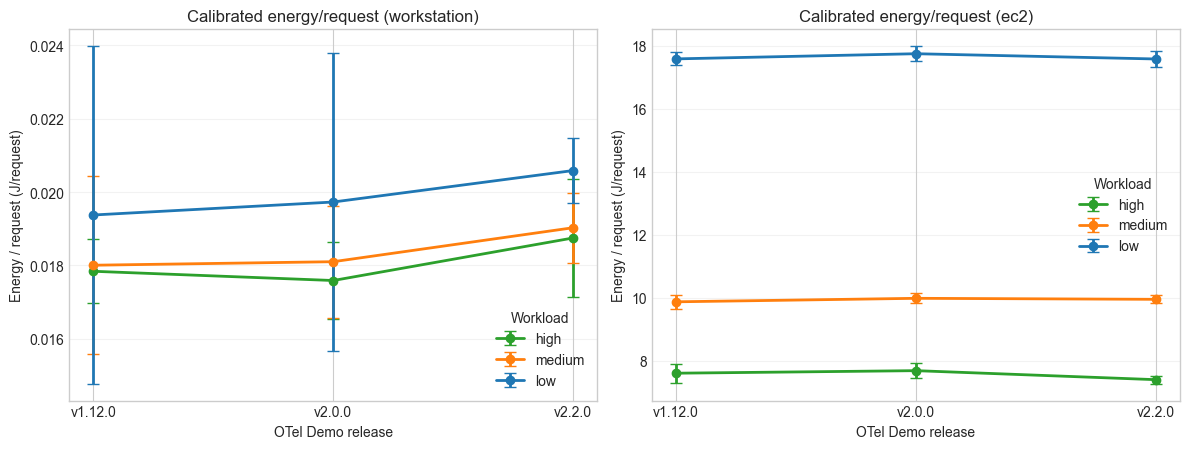

In [ ]:
# Evaluate if normalisation is defensible, then project EC2 model values to meter-calibrated Joules
CV_THRESHOLD = 0.25
COUNT_THRESHOLD = 3

ratio_by_workload = ratio_by_workload.sort_values('workload_level').reset_index(drop=True)
stable_rows = ratio_by_workload[
    (ratio_by_workload['count'] >= COUNT_THRESHOLD)
    & ratio_by_workload['cv'].notna()
    & (ratio_by_workload['cv'] <= CV_THRESHOLD)
]

global_factor = float(ws_dual['ratio_meter_to_model'].median())
workload_factor = {
    row['workload_level']: float(row['median']) for _, row in stable_rows.iterrows()
}

print(f'Normalisation thresholds: count >= {COUNT_THRESHOLD}, cv <= {CV_THRESHOLD:.2f}')
print(f'Global fallback factor (median workstation meter/model): {global_factor:.4f}')
print('Stable workload-specific factors:', workload_factor)

normalisation_plausible = len(workload_factor) >= 2
print('Is cross-source normalisation plausible?', bool(normalisation_plausible))

ec2_model = norm_source_df[
    (norm_source_df['environment'] == 'ec2') & norm_source_df['model_epr_j'].notna()
].copy()
if ec2_model.empty:
    raise RuntimeError('No EC2 model energy/request values found for projection')

wl_key = ec2_model['workload_level'].astype(str)
ec2_model['normalisation_factor'] = wl_key.map(workload_factor).astype(float)
ec2_model['normalisation_factor'] = ec2_model['normalisation_factor'].fillna(global_factor)
ec2_model['projected_meter_epr_j'] = ec2_model['model_epr_j'] * ec2_model['normalisation_factor']

ws_meter = norm_source_df[
    (norm_source_df['environment'] == 'workstation') & norm_source_df['meter_epr_j'].notna()
].copy()
ws_meter['projected_meter_epr_j'] = ws_meter['meter_epr_j']

comparison_df = pd.concat([
    ws_meter[['environment', 'release', 'workload_level', 'projected_meter_epr_j']].rename(columns={'environment': 'env'}),
    ec2_model[['environment', 'release', 'workload_level', 'projected_meter_epr_j']].rename(columns={'environment': 'env'}),
])

comparison_summary = (
    comparison_df.groupby(['env', 'release', 'workload_level'], observed=True)['projected_meter_epr_j']
                 .agg(['mean', 'std', 'count'])
                 .reset_index()
                 .sort_values(['env', 'workload_level', 'release'])
                 .reset_index(drop=True)
)

print('Projected comparable energy/request in Joules (workstation uses meter, EC2 uses calibrated model):')
display(comparison_summary.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)
color_map = {'high': '#2ca02c', 'medium': '#ff7f0e', 'low': '#1f77b4'}

for ax_idx, env_name in enumerate(['workstation', 'ec2']):
    ax = axes[ax_idx]
    env_data = comparison_summary[comparison_summary['env'] == env_name]

    for wl in WORKLOAD_ORDER_PAPER:
        s = env_data[env_data['workload_level'] == wl].sort_values('release')
        if s.empty:
            continue
        ax.errorbar(
            s['release'].astype(str),
            s['mean'],
            yerr=s['std'].fillna(0),
            marker='o',
            linewidth=2,
            capsize=4,
            color=color_map[wl],
            label=wl,
        )

    ax.set_title(f'Calibrated energy/request ({env_name})')
    ax.set_xlabel('OTel Demo release')
    ax.set_ylabel('Energy / request (J/request)')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(title='Workload')

fig.tight_layout()
_save_figure(fig, 'chart4b_calibrated_cross_source_comparison')
plt.show()

Selected percentile baseline: p50
Fixed-util filtered runs: 39


,environment,release,workload_level,mean_energy_per_request_j,std_energy_per_request_j,n,mean_selected_cpu
0,workstation,v1.12.0,high,0.001042,0.000038,2,8.524915
1,workstation,v2.0.0,high,0.001079,0.000026,4,8.621361
2,workstation,v2.2.0,high,0.001051,0.000045,4,8.448166
3,workstation,v1.12.0,medium,0.001200,0.000045,3,7.736291
4,workstation,v2.0.0,medium,0.001206,0.000026,5,7.833539
5,workstation,v2.2.0,medium,0.001174,0.000000,1,7.750402
6,workstation,v1.12.0,low,0.002036,0.000000,1,6.313039
7,ec2,v1.12.0,high,0.480871,0.000000,1,9.244637
8,ec2,v2.0.0,high,0.468291,0.005499,3,9.180881
9,ec2,v2.2.0,high,0.440962,0.009367,2,9.055185


Saved: figures/chart4_fixed_util_p50_workstation.png
Saved: figures/chart4_fixed_util_p50_workstation.pdf


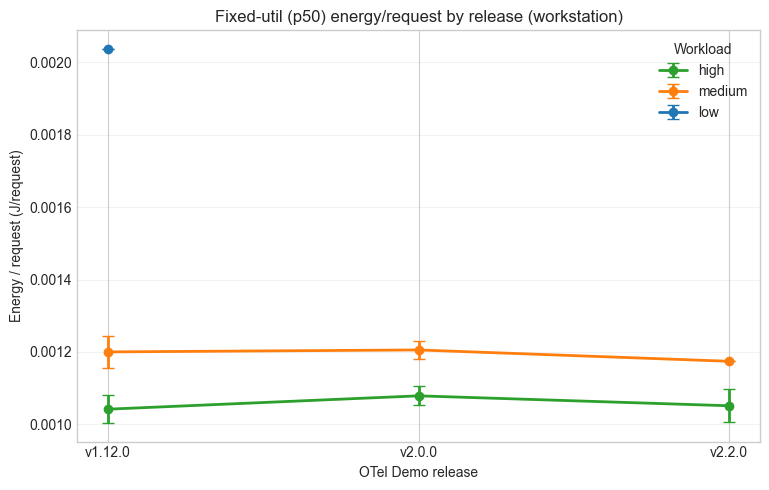

Saved: figures/chart4_fixed_util_p50_ec2.png
Saved: figures/chart4_fixed_util_p50_ec2.pdf


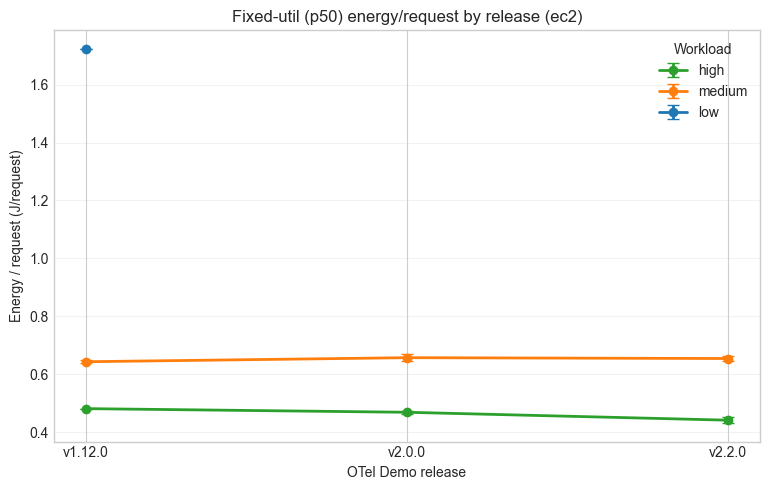

In [ ]:
# Select baseline percentile (prefer p80 when coverage is complete), then compare energy/request inside shared CPU windows
TARGET_PERCENTILE = 80

row80 = coverage_tbl[coverage_tbl['percentile'] == TARGET_PERCENTILE]
if not row80.empty and float(row80['overlap_rate'].iloc[0]) >= 1.0:
    selected_percentile = TARGET_PERCENTILE
else:
    selected_percentile = int(coverage_tbl['percentile'].iloc[0])

print(f'Selected percentile baseline: p{selected_percentile}')

selected_overlap = overlap_df[
    (overlap_df['percentile'] == selected_percentile) & (overlap_df['has_overlap'])
][['release', 'workload_level', 'overlap_low', 'overlap_high']].copy()

selected_cpu_col = f'cpu_p{selected_percentile}'
fixed_util_selected = fixed_util_df.merge(
    selected_overlap,
    on=['release', 'workload_level'],
    how='inner',
)

fixed_util_selected = fixed_util_selected[
    (fixed_util_selected[selected_cpu_col] >= fixed_util_selected['overlap_low'])
    & (fixed_util_selected[selected_cpu_col] <= fixed_util_selected['overlap_high'])
]

if fixed_util_selected.empty:
    raise RuntimeError('No runs left after fixed-util overlap filtering')

fixed_util_summary = (
    fixed_util_selected.groupby(['environment', 'release', 'workload_level'], observed=True)
                      .agg(
                          mean_energy_per_request_j=('energy_per_request_j', 'mean'),
                          std_energy_per_request_j=('energy_per_request_j', 'std'),
                          n=('energy_per_request_j', 'size'),
                          mean_selected_cpu=('cpu_mean', 'mean'),
                      )
                      .reset_index()
)

fixed_util_summary['std_energy_per_request_j'] = fixed_util_summary['std_energy_per_request_j'].fillna(0.0)

print('Fixed-util filtered runs:', len(fixed_util_selected))
display(
    fixed_util_summary.sort_values(['environment', 'workload_level', 'release'])
                      .reset_index(drop=True)
                      .round(6)
)

colors = {'high': '#2ca02c', 'medium': '#ff7f0e', 'low': '#1f77b4'}
for env in ENV_ORDER_PAPER:
    fig, ax = plt.subplots(figsize=(7.8, 5.0))
    env_data = fixed_util_summary[fixed_util_summary['environment'] == env]

    for wl in WORKLOAD_ORDER_PAPER:
        s = env_data[env_data['workload_level'] == wl].sort_values('release')
        if s.empty:
            continue
        ax.errorbar(
            s['release'].astype(str),
            s['mean_energy_per_request_j'],
            yerr=s['std_energy_per_request_j'],
            marker='o',
            linewidth=2,
            capsize=4,
            color=colors[wl],
            label=wl,
        )

    panel = 'workstation' if env == 'workstation' else 'ec2'
    ax.set_title(f'Fixed-util (p{selected_percentile}) energy/request by release ({panel})')
    ax.set_xlabel('OTel Demo release')
    ax.set_ylabel('Energy / request (J/request)')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(title='Workload')

    fig.tight_layout()
    _save_figure(fig, f'chart4_fixed_util_p{selected_percentile}_{panel}')
    plt.show()

In [36]:
# Per-iteration fixed-util table: include energy/request, total energy, and request count
if 'fixed_util_selected' not in globals() or fixed_util_selected.empty:
    raise RuntimeError(
        'fixed_util_selected is missing or empty. Run the fixed-util cells first to build percentile-filtered runs.'
    )

def _first_numeric_value(run: dict, keys: list[str]) -> float:
    for key in keys:
        val = pd.to_numeric(run.get(key), errors='coerce')
        if pd.notna(val):
            return float(val)
    return float('nan')

metric_rows = []
for folder_name, release in RELEASE_MAP_PAPER.items():
    release_dir = RUNS_ROOT / folder_name
    if not release_dir.exists():
        continue

    for experiment_dir in sorted(release_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue

        env = environment_from_folder(experiment_dir.name)
        if env is None:
            continue

        dashboard_path = experiment_dir / 'runs_comparison.html'
        if not dashboard_path.exists():
            continue

        payload = extract_json_object_after_marker(
            dashboard_path.read_text(encoding='utf-8'),
            'const data = ',
        )

        for run in payload.get('runs', []):
            wl = str(run.get('workload_level', '')).lower()
            if wl not in WORKLOAD_ORDER_PAPER:
                continue

            run_name = str(run.get('name', ''))
            iteration_name = pd.Series([run_name]).str.extract(r'(iteration_[0-9_]+)', expand=False).iloc[0]
            if pd.isna(iteration_name):
                continue

            total_energy_j = _first_numeric_value(
                run,
                ['meter_corrected_energy_joules', 'energy_total', 'total_system_energy_j'],
            )

            request_count = _first_numeric_value(
                run,
                [
                    'requests',
                    'request_count',
                    'total_requests',
                    'successful_requests',
                    'num_requests',
                    'num_requests_total',
                ],
            )

            if pd.isna(request_count):
                epr_j = _first_numeric_value(
                    run,
                    ['meter_energy_per_request_joules', 'energy_per_request'],
                )
                if pd.notna(total_energy_j) and pd.notna(epr_j) and epr_j > 0:
                    request_count = total_energy_j / epr_j

            metric_rows.append({
                'release': release,
                'environment': env,
                'workload_level': wl,
                'experiment_folder': experiment_dir.name,
                'iteration_name': str(iteration_name),
                'total_energy_joules': total_energy_j,
                'request_count': request_count,
            })

iteration_metrics_df = pd.DataFrame(metric_rows)
if iteration_metrics_df.empty:
    raise RuntimeError('Could not parse per-iteration total energy/request metrics from dashboards')

join_keys = ['release', 'environment', 'workload_level', 'experiment_folder', 'iteration_name']
fixed_with_metrics = fixed_util_selected.merge(iteration_metrics_df, on=join_keys, how='left')

base_cols = [
    'environment',
    'release',
    'workload_level',
    'experiment_folder',
    'iteration_name',
    selected_cpu_col,
    'overlap_low',
    'overlap_high',
    'energy_per_request_j',
    'total_energy_joules',
    'request_count',
]
optional_cols = [c for c in ['energy_source'] if c in fixed_with_metrics.columns]

iteration_fixed_util_table = fixed_with_metrics[base_cols + optional_cols].copy()
iteration_fixed_util_table = iteration_fixed_util_table.rename(columns={
    selected_cpu_col: f'cpu_p{selected_percentile}',
    'energy_per_request_j': 'energy_joules_per_request',
})

iteration_fixed_util_table = iteration_fixed_util_table.sort_values(
    ['environment', 'release', 'workload_level', 'experiment_folder', 'iteration_name']
).reset_index(drop=True)

print(
    f"Iterations in fixed-util table: {len(iteration_fixed_util_table)} "
    f"(percentile baseline = p{selected_percentile})"
)

missing_total = int(iteration_fixed_util_table['total_energy_joules'].isna().sum())
missing_req = int(iteration_fixed_util_table['request_count'].isna().sum())
print(f'Missing total_energy_joules rows: {missing_total}')
print(f'Missing request_count rows: {missing_req}')

display(iteration_fixed_util_table.round(6))

Iterations in fixed-util table: 39 (percentile baseline = p50)
Missing total_energy_joules rows: 0
Missing request_count rows: 0


,environment,release,workload_level,experiment_folder,iteration_name,cpu_p50,overlap_low,overlap_high,energy_joules_per_request,total_energy_joules,request_count
0,ec2,v1.12.0,high,julian_20260602_080130_345155_otel-demo,iteration_20260602_100322_786255,9.149552,8.986489,9.149552,0.480871,6509.072891,13536.0
1,ec2,v1.12.0,low,julian_20260602_080130_345155_otel-demo,iteration_20260602_080825_513816,6.785857,6.785857,6.791415,1.723051,4000.923358,2322.0
2,ec2,v1.12.0,medium,julian_20260602_080130_345155_otel-demo,iteration_20260602_085130_876861,8.380758,8.245344,8.610624,0.643342,5073.392266,7886.0
3,ec2,v1.12.0,medium,julian_20260602_080130_345155_otel-demo,iteration_20260602_085838_488304,8.343630,8.245344,8.610624,0.650936,5161.921986,7930.0
4,ec2,v1.12.0,medium,julian_20260602_080130_345155_otel-demo,iteration_20260602_090551_308727,8.245344,8.245344,8.610624,0.637293,5001.472350,7848.0
5,ec2,v1.12.0,medium,julian_20260602_080130_345155_otel-demo,iteration_20260602_091304_294105,8.507526,8.245344,8.610624,0.640161,5026.545061,7852.0
6,ec2,v2.0.0,high,julian_20260602_112108_629923_otel-demo-2.0.0,iteration_20260602_125453_094838,9.073869,9.059137,9.388489,0.473925,6398.465172,13501.0
7,ec2,v2.0.0,high,julian_20260602_112108_629923_otel-demo-2.0.0,iteration_20260602_130910_252943,9.113448,9.059137,9.388489,0.468009,6304.551799,13471.0
8,ec2,v2.0.0,high,julian_20260602_112108_629923_otel-demo-2.0.0,iteration_20260602_132329_227399,9.388489,9.059137,9.388489,0.462937,6268.172085,13540.0
9,ec2,v2.0.0,medium,julian_20260602_112108_629923_otel-demo-2.0.0,iteration_20260602_121850_306966,8.558826,8.460999,8.732680,0.668662,5253.677266,7857.0


In [38]:
# Consistent-source per-iteration EPR for cross-environment comparison
# Choose one policy:
# - 'model_only': use model/Kepler EPR for both environments
# - 'meter_only_workstation': use only workstation meter EPR (EC2 remains NaN)
# - 'calibrated_meter_equivalent': workstation meter EPR, EC2 model EPR scaled by workstation meter/model ratio
SOURCE_POLICY = 'model_only'

if 'fixed_util_selected' not in globals() or fixed_util_selected.empty:
    raise RuntimeError(
        'fixed_util_selected is missing or empty. Run the fixed-util cells first to build percentile-filtered runs.'
    )


def _extract_iteration_energy_fields(runs_root: Path) -> pd.DataFrame:
    rows = []
    for folder_name, release in RELEASE_MAP_PAPER.items():
        release_dir = runs_root / folder_name
        if not release_dir.exists():
            continue

        for experiment_dir in sorted(release_dir.iterdir()):
            if not experiment_dir.is_dir():
                continue

            env = environment_from_folder(experiment_dir.name)
            if env is None:
                continue

            dashboard_path = experiment_dir / 'runs_comparison.html'
            if not dashboard_path.exists():
                continue

            payload = extract_json_object_after_marker(
                dashboard_path.read_text(encoding='utf-8'),
                'const data = ',
            )

            for run in payload.get('runs', []):
                wl = str(run.get('workload_level', '')).lower()
                if wl not in WORKLOAD_ORDER_PAPER:
                    continue

                run_name = str(run.get('name', ''))
                iteration_name = pd.Series([run_name]).str.extract(r'(iteration_[0-9_]+)', expand=False).iloc[0]
                if pd.isna(iteration_name):
                    continue

                rows.append({
                    'release': release,
                    'environment': env,
                    'workload_level': wl,
                    'experiment_folder': experiment_dir.name,
                    'iteration_name': str(iteration_name),
                    'model_epr_j': pd.to_numeric(run.get('energy_per_request'), errors='coerce'),
                    'meter_epr_j': pd.to_numeric(run.get('meter_energy_per_request_joules'), errors='coerce'),
                })

    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError('No per-iteration energy fields found in runs_comparison payloads')
    return out


join_keys = ['release', 'environment', 'workload_level', 'experiment_folder', 'iteration_name']
iter_energy_df = _extract_iteration_energy_fields(RUNS_ROOT)

base_fixed = fixed_util_selected[join_keys + [selected_cpu_col, 'overlap_low', 'overlap_high']].copy()
consistent_df = base_fixed.merge(iter_energy_df, on=join_keys, how='left')

if SOURCE_POLICY == 'model_only':
    consistent_df['consistent_epr_j'] = consistent_df['model_epr_j']
    consistent_df['consistent_source'] = 'model_kepler'
elif SOURCE_POLICY == 'meter_only_workstation':
    consistent_df['consistent_epr_j'] = np.where(
        consistent_df['environment'] == 'workstation',
        consistent_df['meter_epr_j'],
        np.nan,
    )
    consistent_df['consistent_source'] = np.where(
        consistent_df['environment'] == 'workstation',
        'meter_joules',
        'not_available',
    )
elif SOURCE_POLICY == 'calibrated_meter_equivalent':
    ws_pairs = consistent_df[
        (consistent_df['environment'] == 'workstation')
        & consistent_df['meter_epr_j'].notna()
        & consistent_df['model_epr_j'].notna()
        & (consistent_df['model_epr_j'] > 0)
    ].copy()

    if ws_pairs.empty:
        raise RuntimeError('No workstation meter/model pairs available for calibration policy')

    ws_pairs['ratio_meter_to_model'] = ws_pairs['meter_epr_j'] / ws_pairs['model_epr_j']
    factor_by_workload = ws_pairs.groupby('workload_level', observed=True)['ratio_meter_to_model'].median().to_dict()
    global_factor = float(ws_pairs['ratio_meter_to_model'].median())

    wl_key = consistent_df['workload_level'].astype(str)
    ec2_factor = wl_key.map(factor_by_workload).astype(float).fillna(global_factor)

    consistent_df['consistent_epr_j'] = np.where(
        consistent_df['environment'] == 'workstation',
        consistent_df['meter_epr_j'],
        consistent_df['model_epr_j'] * ec2_factor,
    )
    consistent_df['consistent_source'] = np.where(
        consistent_df['environment'] == 'workstation',
        'meter_joules',
        'model_joules_x_ws_calibration',
    )
else:
    raise ValueError(f'Unsupported SOURCE_POLICY: {SOURCE_POLICY}')

consistent_iter_table = consistent_df[[
    'environment',
    'release',
    'workload_level',
    'experiment_folder',
    'iteration_name',
    selected_cpu_col,
    'overlap_low',
    'overlap_high',
    'model_epr_j',
    'meter_epr_j',
    'consistent_epr_j',
    'consistent_source',
]].rename(columns={
    selected_cpu_col: f'cpu_p{selected_percentile}',
})

consistent_iter_table = consistent_iter_table.sort_values(
    ['environment', 'release', 'workload_level', 'experiment_folder', 'iteration_name']
).reset_index(drop=True)

summary_consistent = (
    consistent_iter_table.groupby(['environment', 'release', 'workload_level'], observed=True)['consistent_epr_j']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values(['environment', 'workload_level', 'release'])
    .reset_index(drop=True)
)

print(f'Consistent source policy: {SOURCE_POLICY}')
print('Rows with missing consistent_epr_j:', int(consistent_iter_table['consistent_epr_j'].isna().sum()))
print('Source labels used:', sorted(consistent_iter_table['consistent_source'].dropna().unique().tolist()))

print('\nPer-iteration consistent EPR table:')
display(consistent_iter_table.round(6))

print('\nGrouped summary (consistent EPR):')
display(summary_consistent.round(6))

Consistent source policy: model_only
Rows with missing consistent_epr_j: 0
Source labels used: ['model_kepler']

Per-iteration consistent EPR table:


,environment,release,workload_level,experiment_folder,iteration_name,cpu_p50,overlap_low,overlap_high,model_epr_j,meter_epr_j,consistent_epr_j,consistent_source
0,ec2,v1.12.0,high,julian_20260602_080130_345155_otel-demo,iteration_20260602_100322_786255,9.149552,8.986489,9.149552,0.480871,NaN,0.480871,model_kepler
1,ec2,v1.12.0,low,julian_20260602_080130_345155_otel-demo,iteration_20260602_080825_513816,6.785857,6.785857,6.791415,1.723051,NaN,1.723051,model_kepler
2,ec2,v1.12.0,medium,julian_20260602_080130_345155_otel-demo,iteration_20260602_085130_876861,8.380758,8.245344,8.610624,0.643342,NaN,0.643342,model_kepler
3,ec2,v1.12.0,medium,julian_20260602_080130_345155_otel-demo,iteration_20260602_085838_488304,8.343630,8.245344,8.610624,0.650936,NaN,0.650936,model_kepler
4,ec2,v1.12.0,medium,julian_20260602_080130_345155_otel-demo,iteration_20260602_090551_308727,8.245344,8.245344,8.610624,0.637293,NaN,0.637293,model_kepler
5,ec2,v1.12.0,medium,julian_20260602_080130_345155_otel-demo,iteration_20260602_091304_294105,8.507526,8.245344,8.610624,0.640161,NaN,0.640161,model_kepler
6,ec2,v2.0.0,high,julian_20260602_112108_629923_otel-demo-2.0.0,iteration_20260602_125453_094838,9.073869,9.059137,9.388489,0.473925,NaN,0.473925,model_kepler
7,ec2,v2.0.0,high,julian_20260602_112108_629923_otel-demo-2.0.0,iteration_20260602_130910_252943,9.113448,9.059137,9.388489,0.468009,NaN,0.468009,model_kepler
8,ec2,v2.0.0,high,julian_20260602_112108_629923_otel-demo-2.0.0,iteration_20260602_132329_227399,9.388489,9.059137,9.388489,0.462937,NaN,0.462937,model_kepler
9,ec2,v2.0.0,medium,julian_20260602_112108_629923_otel-demo-2.0.0,iteration_20260602_121850_306966,8.558826,8.460999,8.732680,0.668662,NaN,0.668662,model_kepler



Grouped summary (consistent EPR):


,environment,release,workload_level,mean,std,count
0,ec2,v1.12.0,high,0.480871,NaN,1
1,ec2,v2.0.0,high,0.468291,0.005499,3
2,ec2,v2.2.0,high,0.440962,0.009367,2
3,ec2,v1.12.0,low,1.723051,NaN,1
4,ec2,v1.12.0,medium,0.642933,0.005880,4
5,ec2,v2.0.0,medium,0.656889,0.011064,3
6,ec2,v2.2.0,medium,0.653963,0.008497,5
7,workstation,v1.12.0,high,0.001042,0.000038,2
8,workstation,v2.0.0,high,0.001079,0.000026,4
9,workstation,v2.2.0,high,0.001051,0.000045,4


Per-release averages used for simplified plots:


,environment,release,mean_consistent_epr_j,std_consistent_epr_j,n_iterations,n_workloads
0,ec2,v1.12.0,0.795942,0.458814,6,3
1,ec2,v2.0.0,0.562590,0.103595,6,2
2,ec2,v2.2.0,0.593105,0.104235,7,2
3,workstation,v1.12.0,0.001287,0.000377,6,3
4,workstation,v2.0.0,0.001149,0.000071,9,2
5,workstation,v2.2.0,0.001076,0.000067,5,2


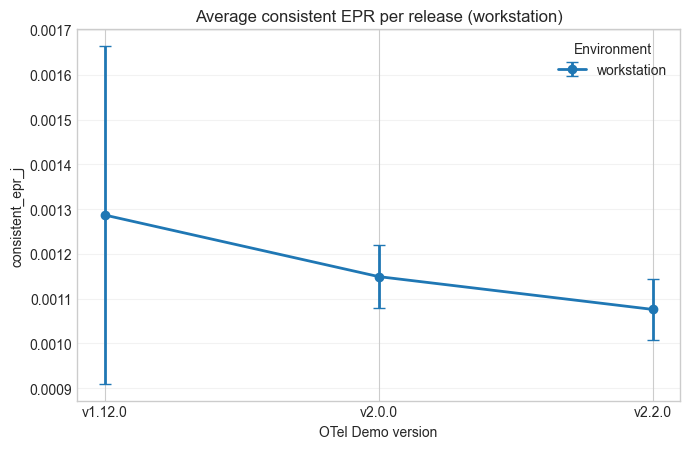

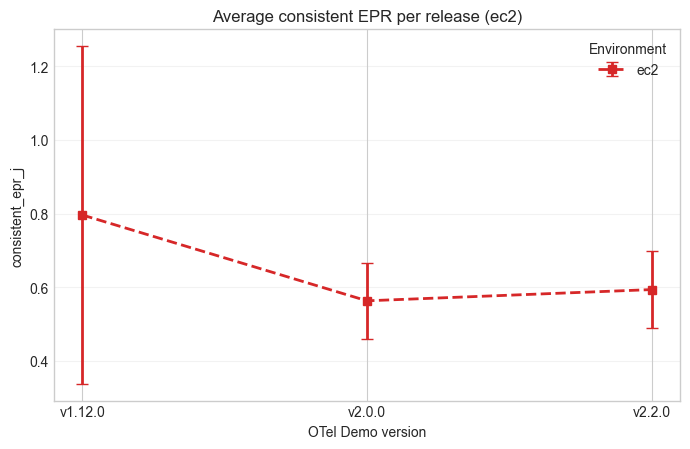

In [41]:
# Simplified view: average consistent_epr_j per release, plotted separately per environment
if 'consistent_iter_table' not in globals() or consistent_iter_table.empty:
    raise RuntimeError('consistent_iter_table is missing or empty. Run the previous consistent-source cell first.')

release_avg_df = (
    consistent_iter_table.groupby(['environment', 'release'], observed=True)
    .agg(
        mean_consistent_epr_j=('consistent_epr_j', 'mean'),
        std_consistent_epr_j=('consistent_epr_j', 'std'),
        n_iterations=('consistent_epr_j', 'size'),
        n_workloads=('workload_level', 'nunique'),
    )
    .reset_index()
)

release_avg_df['release'] = pd.Categorical(
    release_avg_df['release'],
    categories=RELEASE_ORDER_PAPER,
    ordered=True,
)
release_avg_df = release_avg_df.sort_values(['environment', 'release']).reset_index(drop=True)
release_avg_df['std_consistent_epr_j'] = release_avg_df['std_consistent_epr_j'].fillna(0.0)

print('Per-release averages used for simplified plots:')
display(release_avg_df.round(6))

style_map = {
    'workstation': {'color': '#1f77b4', 'linestyle': '-', 'marker': 'o'},
    'ec2': {'color': '#d62728', 'linestyle': '--', 'marker': 's'},
}

for env in ['workstation', 'ec2']:
    s = release_avg_df[release_avg_df['environment'] == env].sort_values('release')
    if s.empty:
        continue

    st = style_map[env]
    fig, ax = plt.subplots(figsize=(7.0, 4.6))
    ax.errorbar(
        s['release'].astype(str),
        s['mean_consistent_epr_j'],
        yerr=s['std_consistent_epr_j'],
        marker=st['marker'],
        linestyle=st['linestyle'],
        linewidth=2,
        capsize=4,
        color=st['color'],
        label=env,
    )

    ax.set_title(f'Average consistent EPR per release ({env})')
    ax.set_xlabel('OTel Demo version')
    ax.set_ylabel('consistent_epr_j')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(title='Environment')

    fig.tight_layout()
    plt.show()

In [42]:
# Diagnostic: explain release-level error bar size by decomposing variance components
if 'consistent_iter_table' not in globals() or consistent_iter_table.empty:
    raise RuntimeError('consistent_iter_table missing; run the consistent-source cell first.')

diag = consistent_iter_table.dropna(subset=['consistent_epr_j']).copy()

overall = (
    diag.groupby(['environment', 'release'], observed=True)['consistent_epr_j']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'std': 'overall_std', 'count': 'n'})
    .reset_index()
)

within = (
    diag.groupby(['environment', 'release', 'workload_level'], observed=True)['consistent_epr_j']
    .agg(wl_mean='mean', wl_std='std', wl_n='size')
    .reset_index()
)
within['wl_std'] = within['wl_std'].fillna(0.0)

within_component = (
    within.groupby(['environment', 'release'], observed=True)
    .apply(lambda g: float(np.sqrt(np.average(g['wl_std'].to_numpy() ** 2, weights=g['wl_n'].to_numpy()))))
    .rename('within_component_std')
    .reset_index()
)

between_component = (
    within.groupby(['environment', 'release'], observed=True)
    .apply(lambda g: float(np.std(np.repeat(g['wl_mean'].to_numpy(), g['wl_n'].to_numpy().astype(int)), ddof=1)) if g['wl_n'].sum() > 1 else 0.0)
    .rename('between_workload_mixed_std')
    .reset_index()
)

diag_summary = overall.merge(within_component, on=['environment', 'release'], how='left')
diag_summary = diag_summary.merge(between_component, on=['environment', 'release'], how='left')
diag_summary['cv'] = diag_summary['overall_std'] / diag_summary['mean']

print('Release-level spread diagnostics (overall vs within-workload):')
display(diag_summary.round(6))

print('Per-workload means/std used in decomposition:')
display(within.sort_values(['environment', 'release', 'workload_level']).round(6))

Release-level spread diagnostics (overall vs within-workload):


/var/folders/84/yf0wflkx5j19fmr6tjfds18m0000gn/T/ipykernel_18411/3761408864.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(np.sqrt(np.average(g['wl_std'].to_numpy() ** 2, weights=g['wl_n'].to_numpy()))))
/var/folders/84/yf0wflkx5j19fmr6tjfds18m0000gn/T/ipykernel_18411/3761408864.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(np.std(np.repeat(g['wl_me

,environment,release,mean,overall_std,n,within_component_std,between_workload_mixed_std,cv
0,ec2,v1.12.0,0.795942,0.458814,6,0.004801,0.458791,0.576441
1,ec2,v2.0.0,0.562590,0.103595,6,0.008737,0.103299,0.184139
2,ec2,v2.2.0,0.593105,0.104235,7,0.008754,0.103934,0.175745
3,workstation,v1.12.0,0.001287,0.000377,6,0.000039,0.000375,0.292736
4,workstation,v2.0.0,0.001149,0.000071,9,0.000026,0.000067,0.061825
5,workstation,v2.2.0,0.001076,0.000067,5,0.000040,0.000055,0.062693


Per-workload means/std used in decomposition:


,environment,release,workload_level,wl_mean,wl_std,wl_n
0,ec2,v1.12.0,high,0.480871,0.000000,1
1,ec2,v1.12.0,low,1.723051,0.000000,1
2,ec2,v1.12.0,medium,0.642933,0.005880,4
3,ec2,v2.0.0,high,0.468291,0.005499,3
4,ec2,v2.0.0,medium,0.656889,0.011064,3
5,ec2,v2.2.0,high,0.440962,0.009367,2
6,ec2,v2.2.0,medium,0.653963,0.008497,5
7,workstation,v1.12.0,high,0.001042,0.000038,2
8,workstation,v1.12.0,low,0.002036,0.000000,1
9,workstation,v1.12.0,medium,0.001200,0.000045,3


Using service for plot: product-catalog
Per-release product-catalog service energy/request summary:


,environment,release,mean_service_epr_j,std_service_epr_j,n_points,n_workloads
0,ec2,v1.12.0,1.281347,1.548960,6,3
1,ec2,v2.0.0,0.563509,0.277123,6,3
2,ec2,v2.2.0,0.543639,0.246765,6,3
3,workstation,v1.12.0,0.006735,0.000299,6,3
4,workstation,v2.0.0,0.006466,0.000457,6,3
5,workstation,v2.2.0,0.006941,0.000284,6,3


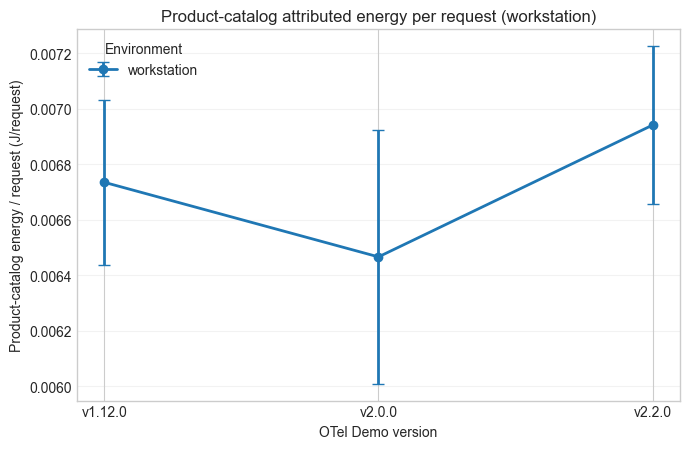

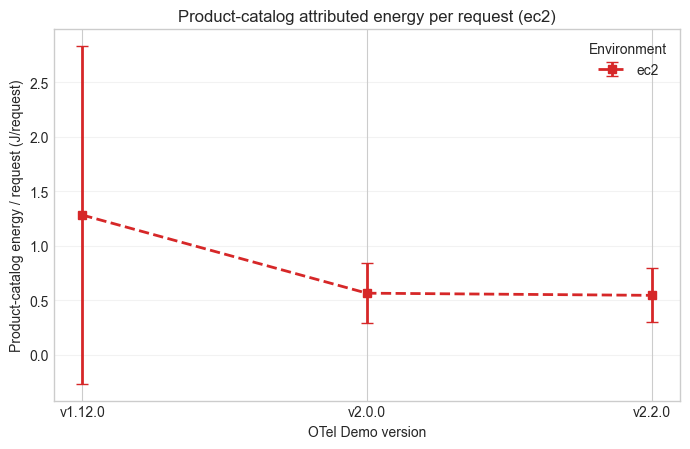

In [43]:
# Product-catalog service: attributed energy per request, plotted per environment by release
if 'attr_df_paper' not in globals() or attr_df_paper.empty:
    raise RuntimeError('attr_df_paper is missing or empty. Run the earlier attribution loading cell first.')

if 'RUNS_ROOT' not in globals():
    raise RuntimeError('RUNS_ROOT is missing. Run the setup cells first.')

service_candidates = sorted(
    [s for s in attr_df_paper['service'].dropna().astype(str).unique() if 'product-catalog' in s]
)
if not service_candidates:
    raise RuntimeError('No product-catalog service found in attribution data.')

service_name = 'product-catalog' if 'product-catalog' in service_candidates else service_candidates[0]
print(f'Using service for plot: {service_name}')

def _first_numeric_value_local(run: dict, keys: list[str]) -> float:
    for key in keys:
        val = pd.to_numeric(run.get(key), errors='coerce')
        if pd.notna(val):
            return float(val)
    return float('nan')

# Build request-count table at the same grouping level as attr_df_paper rows
req_rows = []
for folder_name, release in RELEASE_MAP_PAPER.items():
    release_dir = RUNS_ROOT / folder_name
    if not release_dir.exists():
        continue

    for experiment_dir in sorted(release_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue

        env = environment_from_folder(experiment_dir.name)
        if env is None:
            continue

        dashboard_path = experiment_dir / 'runs_comparison.html'
        if not dashboard_path.exists():
            continue

        payload = extract_json_object_after_marker(
            dashboard_path.read_text(encoding='utf-8'),
            'const data = ',
        )

        for run in payload.get('runs', []):
            wl = str(run.get('workload_level', '')).lower()
            if wl not in WORKLOAD_ORDER_PAPER:
                continue

            request_count = _first_numeric_value_local(
                run,
                [
                    'requests',
                    'request_count',
                    'total_requests',
                    'successful_requests',
                    'num_requests',
                    'num_requests_total',
                ],
            )

            if pd.isna(request_count):
                total_energy_j = _first_numeric_value_local(
                    run,
                    ['meter_corrected_energy_joules', 'energy_total', 'total_system_energy_j'],
                )
                epr_j = _first_numeric_value_local(
                    run,
                    ['meter_energy_per_request_joules', 'energy_per_request'],
                )
                if pd.notna(total_energy_j) and pd.notna(epr_j) and epr_j > 0:
                    request_count = total_energy_j / epr_j

            req_rows.append({
                'release': release,
                'environment': env,
                'workload_level': wl,
                'experiment_folder': experiment_dir.name,
                'request_count': request_count,
            })

requests_df = pd.DataFrame(req_rows)
if requests_df.empty:
    raise RuntimeError('No request count rows could be parsed from dashboards.')

requests_summary = (
    requests_df.groupby(['environment', 'release', 'workload_level', 'experiment_folder'], observed=True)
    .agg(mean_request_count=('request_count', 'mean'))
    .reset_index()
)

svc_df = attr_df_paper[attr_df_paper['service'] == service_name].copy()
svc_with_req = svc_df.merge(
    requests_summary,
    on=['environment', 'release', 'workload_level', 'experiment_folder'],
    how='left',
)
svc_with_req['service_energy_per_request_j'] = (
    svc_with_req['mean_attributed_energy_j'] / svc_with_req['mean_request_count']
)
svc_with_req = svc_with_req.dropna(subset=['service_energy_per_request_j']).copy()

if svc_with_req.empty:
    raise RuntimeError('No product-catalog service energy/request rows after joining attribution and request counts.')

service_release_avg_df = (
    svc_with_req.groupby(['environment', 'release'], observed=True)
    .agg(
        mean_service_epr_j=('service_energy_per_request_j', 'mean'),
        std_service_epr_j=('service_energy_per_request_j', 'std'),
        n_points=('service_energy_per_request_j', 'size'),
        n_workloads=('workload_level', 'nunique'),
    )
    .reset_index()
)

service_release_avg_df['release'] = pd.Categorical(
    service_release_avg_df['release'],
    categories=RELEASE_ORDER_PAPER,
    ordered=True,
)
service_release_avg_df = service_release_avg_df.sort_values(['environment', 'release']).reset_index(drop=True)
service_release_avg_df['std_service_epr_j'] = service_release_avg_df['std_service_epr_j'].fillna(0.0)

print('Per-release product-catalog service energy/request summary:')
display(service_release_avg_df.round(8))

style_map = {
    'workstation': {'color': '#1f77b4', 'linestyle': '-', 'marker': 'o'},
    'ec2': {'color': '#d62728', 'linestyle': '--', 'marker': 's'},
}

for env in ['workstation', 'ec2']:
    s = service_release_avg_df[service_release_avg_df['environment'] == env].sort_values('release')
    if s.empty:
        continue

    st = style_map[env]
    fig, ax = plt.subplots(figsize=(7.0, 4.6))
    ax.errorbar(
        s['release'].astype(str),
        s['mean_service_epr_j'],
        yerr=s['std_service_epr_j'],
        marker=st['marker'],
        linestyle=st['linestyle'],
        linewidth=2,
        capsize=4,
        color=st['color'],
        label=env,
    )

    ax.set_title(f'Product-catalog attributed energy per request ({env})')
    ax.set_xlabel('OTel Demo version')
    ax.set_ylabel('Product-catalog energy / request (J/request)')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(title='Environment')

    fig.tight_layout()
    plt.show()